In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

plt.style.use('default')

## **Problem 1 to 2:**

**Dataset link:** https://rb.gy/gsmddu

**Add a label to every axis and add a proper title for the charts (For every subplot, it is applicable). Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.

### **Problem-1:** Make a subplots which have 2 plots.

- For the first chart, draw a scatter plot "*Monitored Cap.(MW)*" vs "*Total Cap. Under Maintenance (MW)*" of top 5 most frequent power stations. Then draw the lines which indicate the average values of these two columns. Change the colors according to the names of the Power Stations.
- For the second chart, draw a scatter plot "*Monitored Cap. (MW)*" vs "*Actual(MU)*" of the top 5 most frequent power stations. Also draw the lines which indicates the average values of these two columns. Change the colors according to the names of the Power Stations.


In [2]:
df = pd.read_csv('datasets/PowerGeneration.csv')
df.head()

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0


In [3]:
most_freq_ps = df['Power Station'].value_counts().head().index.tolist()
most_freq_ps

['NTPC Ltd.', 'NHPC', 'NPCIL', 'GMR ENERG', 'APL']

In [4]:
temp_df = df[df['Power Station'].isin(most_freq_ps)]
temp_df

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
11,2017-09-01,APL,1320.00,660.00,0.0,660.0,0,22,12,-10.62,0.0
28,2017-09-01,NHPC,4154.20,217.00,0.0,206.0,0,69,75,6.01,0.0
30,2017-09-01,NPCIL,1520.00,0.00,0.0,0.0,0,30,35,5.21,0.0
32,2017-09-01,NTPC Ltd.,12659.06,3364.66,710.0,995.0,0,182,162,-19.98,0.0
47,2017-09-01,APL,7920.00,2970.00,0.0,2970.0,0,122,95,-27.22,0.0
...,...,...,...,...,...,...,...,...,...,...,...
345246,2022-04-13,GMR ENERG,1050.00,0.00,0.0,0.0,0,0,25,2.53,0.0
345257,2022-04-13,NHPC,862.00,146.00,0.0,0.0,146,0,11,2.76,0.0
345260,2022-04-13,NTPC Ltd.,11730.00,1105.00,500.0,500.0,105,0,246,12.26,0.0
345270,2022-04-13,NHPC,105.00,35.00,0.0,35.0,0,0,0,-0.72,0.0


In [5]:
encoder = LabelEncoder()
encoder.fit_transform(temp_df['Power Station'])

array([0, 2, 3, ..., 4, 2, 4], shape=(30624,))

In [32]:
temp_df.loc[:, 'Power Station'] = encoder.fit_transform(temp_df['Power Station'])
temp_df

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
11,2017-09-01,0,1320.00,660.00,0.0,660.0,0,22,12,-10.62,0.0
28,2017-09-01,2,4154.20,217.00,0.0,206.0,0,69,75,6.01,0.0
30,2017-09-01,3,1520.00,0.00,0.0,0.0,0,30,35,5.21,0.0
32,2017-09-01,4,12659.06,3364.66,710.0,995.0,0,182,162,-19.98,0.0
47,2017-09-01,0,7920.00,2970.00,0.0,2970.0,0,122,95,-27.22,0.0
...,...,...,...,...,...,...,...,...,...,...,...
345246,2022-04-13,1,1050.00,0.00,0.0,0.0,0,0,25,2.53,0.0
345257,2022-04-13,2,862.00,146.00,0.0,0.0,146,0,11,2.76,0.0
345260,2022-04-13,4,11730.00,1105.00,500.0,500.0,105,0,246,12.26,0.0
345270,2022-04-13,2,105.00,35.00,0.0,35.0,0,0,0,-0.72,0.0


Text(0.5, 1.0, 'Monitored Vs Actual(MU)')

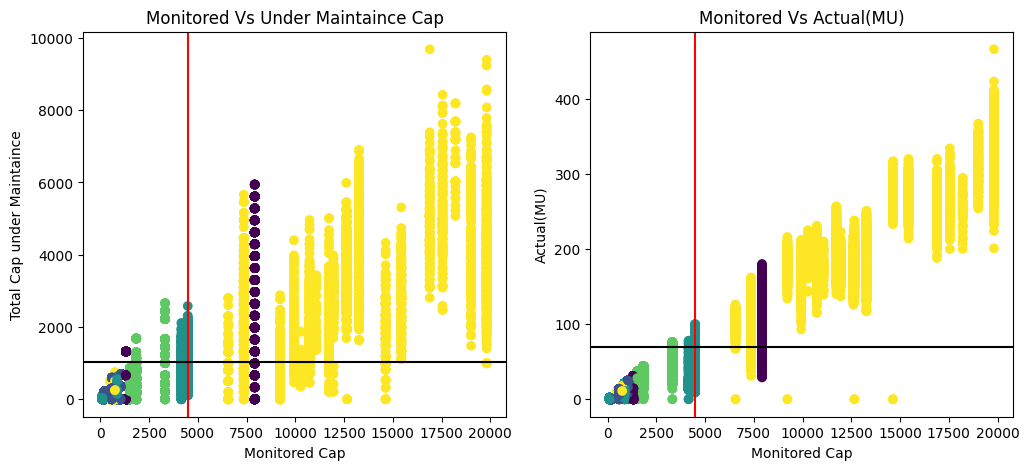

In [17]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].scatter(temp_df['Monitored Cap.(MW)'], temp_df['Total Cap. Under Maintenace (MW)'], c=temp_df['Power Station'])
ax[0].axvline(temp_df['Monitored Cap.(MW)'].mean(), c='red')
ax[0].axhline(temp_df['Total Cap. Under Maintenace (MW)'].mean(), c='black')
ax[0].set_xlabel('Monitored Cap')
ax[0].set_ylabel('Total Cap under Maintaince')
ax[0].set_title('Monitored Vs Under Maintaince Cap')



ax[1].scatter(temp_df['Monitored Cap.(MW)'], temp_df['Actual(MU)'], c=temp_df['Power Station'])
ax[1].axvline(temp_df['Monitored Cap.(MW)'].mean(), c='red')
ax[1].axhline(temp_df['Actual(MU)'].mean(), c='black')
ax[1].set_xlabel('Monitored Cap')
ax[1].set_ylabel('Actual(MU)')
ax[1].set_title('Monitored Vs Actual(MU)')

### **Problem-2:** Draw a 3D Scatter plot between "*Monitored Cap.(MW)*", "*Total Cap. Under Maintenace (MW)*" and "*Forced Maintanence(MW)*"

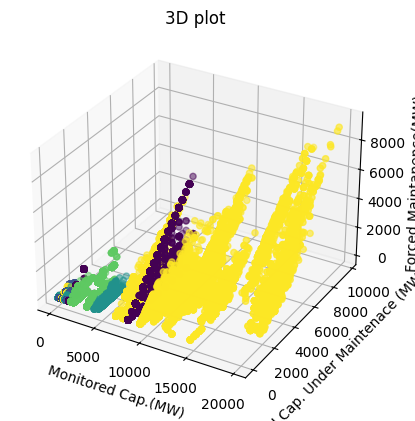

In [22]:
fig = plt.figure()

ax = plt.subplot(projection='3d')

ax.scatter3D(temp_df['Monitored Cap.(MW)'], temp_df['Total Cap. Under Maintenace (MW)'], temp_df['Forced Maintanence(MW)'], c=temp_df['Power Station'])
ax.set_xlabel('Monitored Cap.(MW)')
ax.set_ylabel('Total Cap. Under Maintenace (MW)')
ax.set_zlabel('Forced Maintanence(MW)')
ax.set_title('3D plot')
plt.show()

### **Problem-3:** Make a 3D *Surface* plot of this below mathematical equation.

$$z = |x| - |y|$$

In [23]:
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

xx, yy = np.meshgrid(x,y)

z = np.abs(xx) - np.abs(yy)

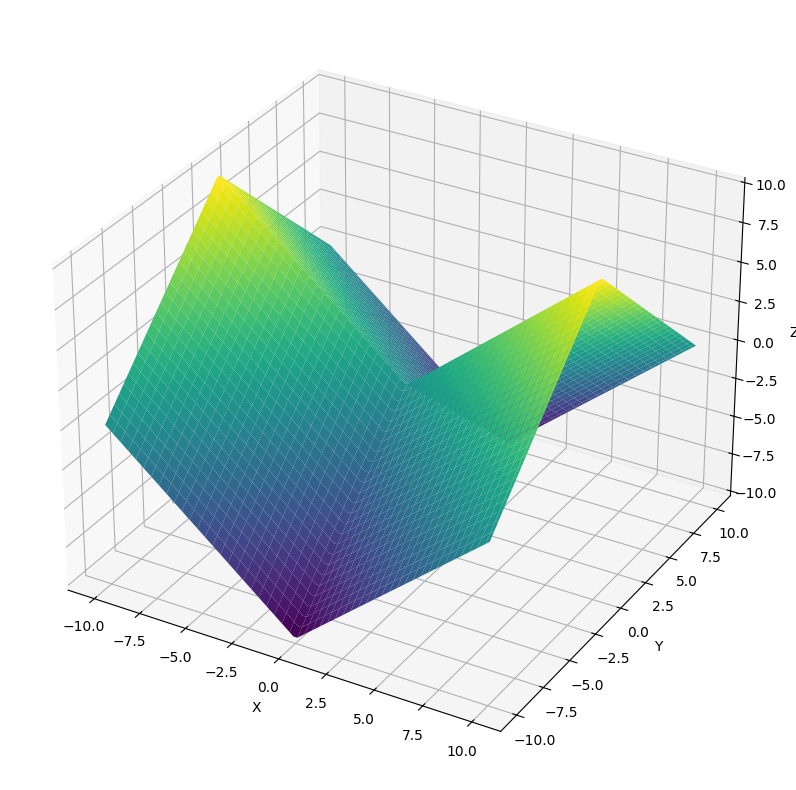

In [25]:
fig = plt.figure(figsize=(10,10))

ax = plt.subplot(projection='3d')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.plot_surface(xx,yy,z, cmap='viridis')

plt.show()

### **Problem-4:** Draw the 3D *Contour plot* of this below equation:

$$z = |x| - |y|$$

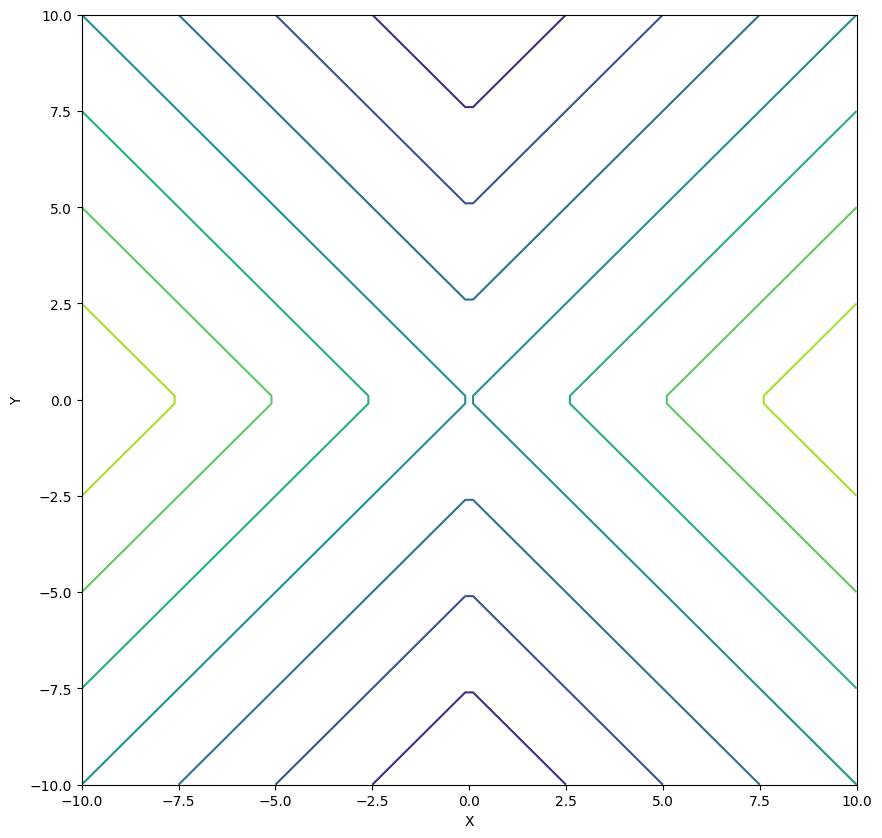

In [30]:
fig = plt.figure(figsize=(10,10))

ax = plt.subplot()
ax.contour(xx,yy,z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()

### **Problem-5:** Draw a second type of Countour plot of the below equation:

$$z = |x| - |y|$$

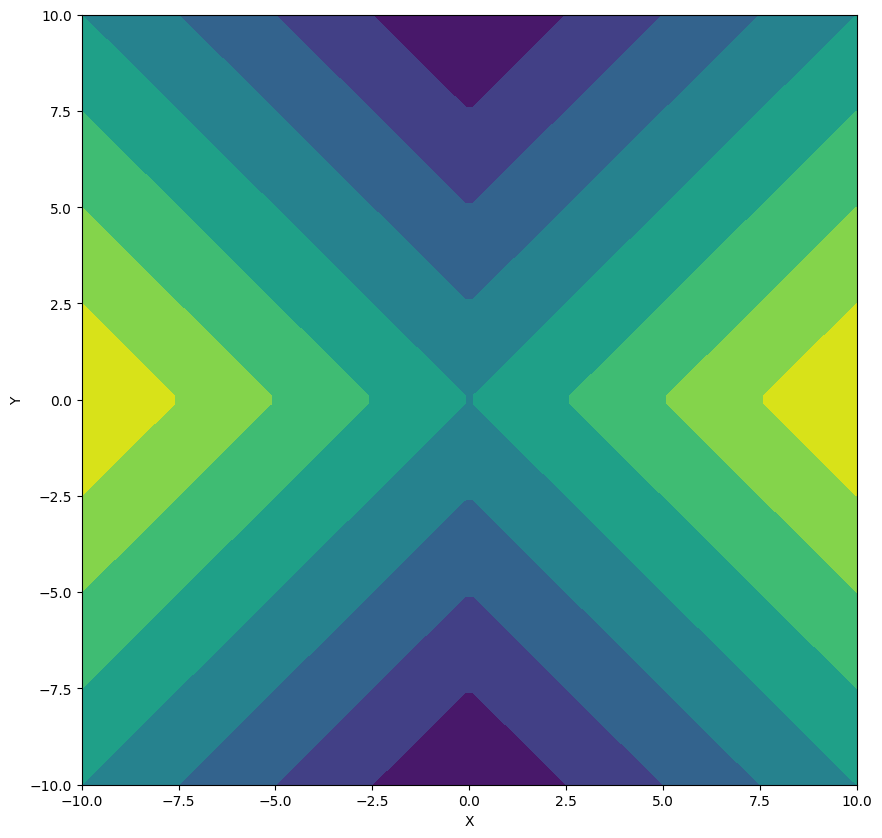

In [31]:
fig = plt.figure(figsize=(10,10))

ax = plt.subplot()
ax.contourf(xx,yy,z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()

## `Problem 6-7`

Data Set Link - https://docs.google.com/spreadsheets/d/17tUL2yC7MGvo7txuuhLtAI-b6_C4jc0t7FLFxqRm-uI/edit?usp=share_link


**Description of Dataset:**

* Date: It gives the date of which stocks details are given.
* Symbol: Name of stock
* Open: It gives the opening price of stock on that date.
* High: It gives the highest price to which the stock ascened on that day.
* Low: It gives the highest price to which the stock plummeted on that day.
* Close: It gives the closing price of stock on that date.
* Volume: It gives the amount of stock traded on that date.
* VWAP: The volume-weighted average price (VWAP) is a statistic used by traders to determine what the average price is based on both price and volume.
* Turnover:

### `Problem-6` Use Pandas plot functions

* Line plot of closing value of top 5 Stocks in Year 2020.
* Take top 5 stocks based on total turnover in Year 2020

In [33]:
nifty = pd.read_csv('datasets/nifty-50.csv')
nifty

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades
0,2000-01-03,HDFCBANK,EQ,157.40,166.00,170.00,166.00,170.00,170.00,169.52,33259,5.638122e+11,NaN
1,2000-01-04,HDFCBANK,EQ,170.00,182.00,183.45,171.00,174.00,173.80,174.99,168710,2.952261e+12,NaN
2,2000-01-05,HDFCBANK,EQ,173.80,170.00,173.90,165.00,168.00,166.95,169.20,159820,2.704094e+12,NaN
3,2000-01-06,HDFCBANK,EQ,166.95,168.00,170.00,165.30,168.95,168.30,168.44,85026,1.432166e+12,NaN
4,2000-01-07,HDFCBANK,EQ,168.30,162.15,171.00,162.15,170.75,168.35,166.79,85144,1.420158e+12,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
480991,2021-04-26,POWERGRID,EQ,211.15,208.20,216.45,208.20,215.75,215.80,213.23,10765892,2.295642e+14,72260.0
480992,2021-04-27,POWERGRID,EQ,215.80,216.05,220.50,215.80,216.40,216.65,217.89,8589721,1.871605e+14,77004.0
480993,2021-04-28,POWERGRID,EQ,216.65,218.80,221.70,216.30,221.35,220.90,219.20,9215766,2.020103e+14,55866.0
480994,2021-04-29,POWERGRID,EQ,220.90,223.10,223.65,219.05,219.80,220.15,220.60,8303610,1.831748e+14,48655.0


In [34]:
nifty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480996 entries, 0 to 480995
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Date        480996 non-null  object 
 1   Symbol      480996 non-null  object 
 2   Series      480996 non-null  object 
 3   Prev Close  480996 non-null  float64
 4   Open        480996 non-null  float64
 5   High        480996 non-null  float64
 6   Low         480996 non-null  float64
 7   Last        480996 non-null  float64
 8   Close       480996 non-null  float64
 9   VWAP        480996 non-null  float64
 10  Volume      480996 non-null  int64  
 11  Turnover    480996 non-null  float64
 12  Trades      245600 non-null  float64
dtypes: float64(9), int64(1), object(3)
memory usage: 47.7+ MB


In [37]:
nifty['Date'] = pd.to_datetime(nifty['Date'])

In [38]:
nifty.set_index('Date', inplace=True)

In [39]:
nifty.head()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades
Date,,,,,,,,,,,,
2000-01-03,HDFCBANK,EQ,157.40,166.00,170.00,166.00,170.00,170.00,169.52,33259,5.638122e+11,NaN
2000-01-04,HDFCBANK,EQ,170.00,182.00,183.45,171.00,174.00,173.80,174.99,168710,2.952261e+12,NaN
2000-01-05,HDFCBANK,EQ,173.80,170.00,173.90,165.00,168.00,166.95,169.20,159820,2.704094e+12,NaN
2000-01-06,HDFCBANK,EQ,166.95,168.00,170.00,165.30,168.95,168.30,168.44,85026,1.432166e+12,NaN
2000-01-07,HDFCBANK,EQ,168.30,162.15,171.00,162.15,170.75,168.35,166.79,85144,1.420158e+12,NaN


In [41]:
temp_df = nifty[nifty.index.year == 2020]
temp_df.head()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades
Date,,,,,,,,,,,,
2020-01-01,HDFCBANK,EQ,1272.10,1276.1,1280.00,1270.60,1279.00,1278.60,1276.64,1836849,2.345001e+14,46625.0
2020-01-02,HDFCBANK,EQ,1278.60,1279.0,1288.00,1279.00,1286.00,1286.75,1284.56,3068583,3.941792e+14,104570.0
2020-01-03,HDFCBANK,EQ,1286.75,1282.2,1285.00,1263.60,1268.50,1268.40,1270.48,5427775,6.895886e+14,157066.0
2020-01-06,HDFCBANK,EQ,1268.40,1260.0,1261.80,1236.00,1240.25,1240.95,1247.24,5445093,6.791348e+14,155007.0
2020-01-07,HDFCBANK,EQ,1240.95,1258.9,1271.45,1252.25,1261.00,1260.60,1261.48,7362247,9.287302e+14,189026.0


In [46]:
top_5 = temp_df.groupby('Symbol')['Turnover'].sum().sort_values(ascending=False).head().index
top_5

Index(['RELIANCE', 'BAJFINANCE', 'HDFCBANK', 'ICICIBANK', 'SBIN'], dtype='object', name='Symbol')

In [50]:
temp_df = temp_df[temp_df['Symbol'].isin(top_5)]
temp_df.head()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades
Date,,,,,,,,,,,,
2020-01-01,HDFCBANK,EQ,1272.10,1276.1,1280.00,1270.60,1279.00,1278.60,1276.64,1836849,2.345001e+14,46625.0
2020-01-02,HDFCBANK,EQ,1278.60,1279.0,1288.00,1279.00,1286.00,1286.75,1284.56,3068583,3.941792e+14,104570.0
2020-01-03,HDFCBANK,EQ,1286.75,1282.2,1285.00,1263.60,1268.50,1268.40,1270.48,5427775,6.895886e+14,157066.0
2020-01-06,HDFCBANK,EQ,1268.40,1260.0,1261.80,1236.00,1240.25,1240.95,1247.24,5445093,6.791348e+14,155007.0
2020-01-07,HDFCBANK,EQ,1240.95,1258.9,1271.45,1252.25,1261.00,1260.60,1261.48,7362247,9.287302e+14,189026.0


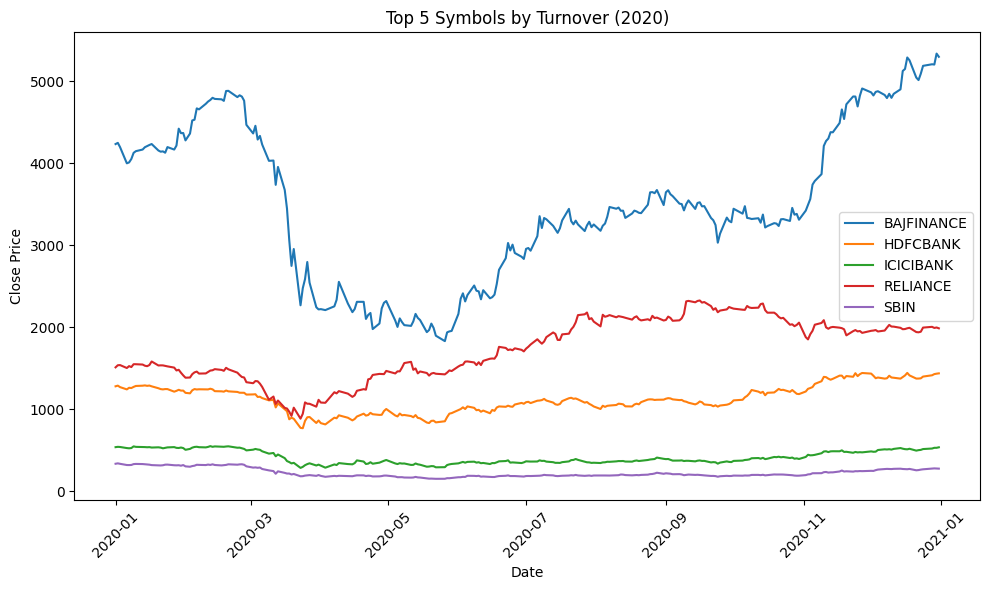

In [59]:
plt.figure(figsize=(10, 6))

for name, group in temp_df.groupby('Symbol'):
    group = group.sort_index()
    plt.plot(group.index, group['Close'], label=name)

plt.legend()
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Top 5 Symbols by Turnover (2020)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### `Problem-7` Scatter plot Close price vs Volume for TOP-5 Stocks in year 2021
* Color on Symbol Column

<Axes: xlabel='Close', ylabel='Volume'>

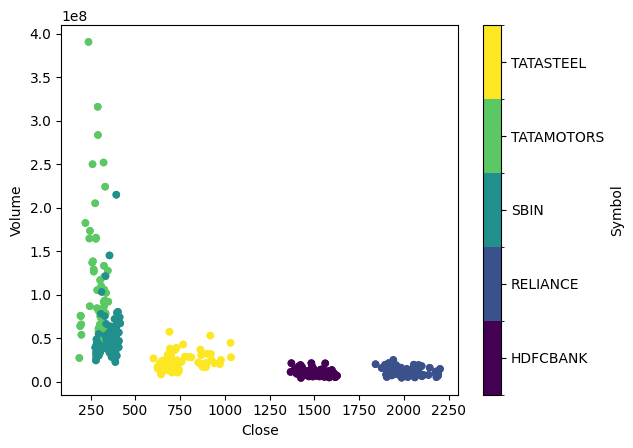

In [63]:
temp_df = nifty[nifty.index.year == 2021]
top_5 = temp_df.groupby('Symbol')['Turnover'].sum().sort_values(ascending=False).head().index
temp_df = temp_df[temp_df['Symbol'].isin(top_5)]

temp_df['Symbol'] = temp_df['Symbol'].astype('category')
temp_df.plot(kind='scatter', x='Close', y='Volume', c='Symbol', colormap='viridis')

### `Problem-8` Create a 3-D Scatter Plot using `time,x,y` on below synthetic data. and give color gradiant on `z`
```
# Create a 3D dataset
time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

# Create a DataFrame from the dataset
data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})
```

In [65]:
# Create a 3D dataset
time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

# Create a DataFrame from the dataset
data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})

data

,time,x,y,z
0,0.00000,0.000000,1.000000,0.00000
1,0.10101,0.100838,0.994903,0.10101
2,0.20202,0.200649,0.979663,0.20202
3,0.30303,0.298414,0.954437,0.30303
4,0.40404,0.393137,0.919480,0.40404
...,...,...,...,...
95,9.59596,-0.170347,-0.985384,9.59596
96,9.69697,-0.268843,-0.963184,9.69697
97,9.79798,-0.364599,-0.931165,9.79798
98,9.89899,-0.456637,-0.889653,9.89899


Text(0.5, 0.92, 'Vibration Characterstics of a car body')

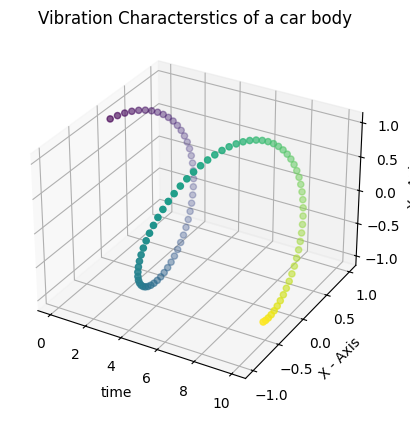

In [68]:
fig = plt.figure()

ax = plt.axes(projection='3d')

ax.scatter(data['time'], data['x'], data['y'], c=data['z'])

ax.set_xlabel('time')
ax.set_ylabel('X - Axis')
ax.set_zlabel('Y - Axis')

plt.title('Vibration Characterstics of a car body')

### `Problem 9:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = sin(\sqrt{x^2 + y^2})$$


In [81]:
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

xx,yy = np.meshgrid(x,y)

z = np.sin(np.sqrt(xx**2 + yy**2))

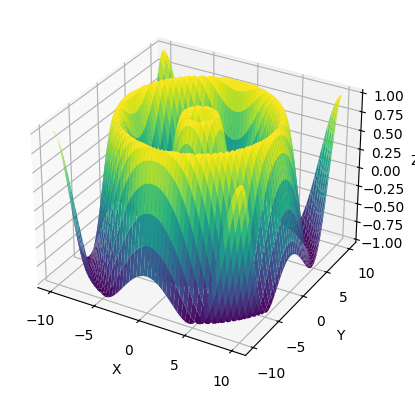

In [82]:
fig = plt.figure()

ax = plt.subplot(projection='3d')
ax.plot_surface(xx,yy,z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()


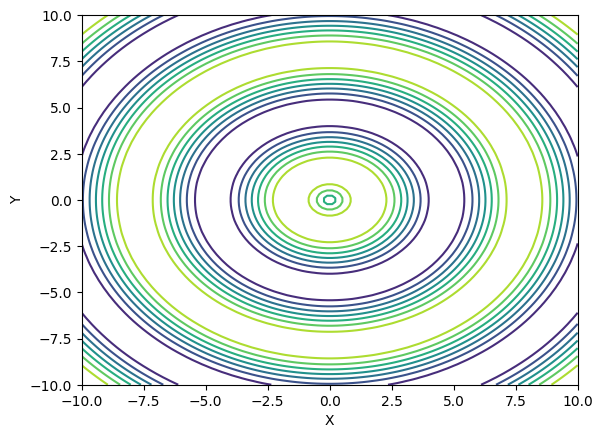

In [74]:
fig = plt.figure()

ax = plt.subplot()
ax.contour(xx,yy,z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()


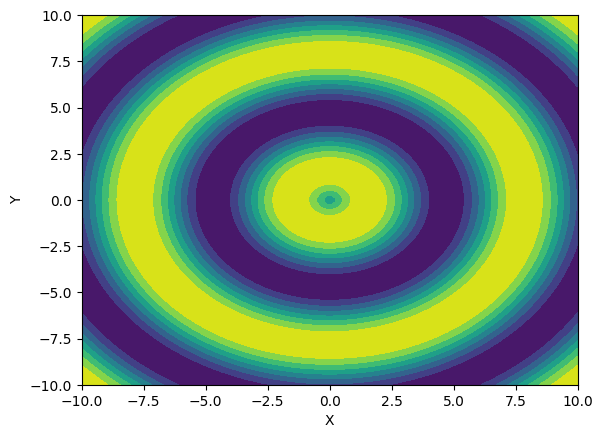

In [75]:
fig = plt.figure()

ax = plt.subplot()
ax.contourf(xx,yy,z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()


### `Problem 10:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = tan(\log_2({x^2 + y^2})$$

In [85]:
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

xx,yy = np.meshgrid(x,y)

z = np.tan(np.log2(xx**2 + yy**2))

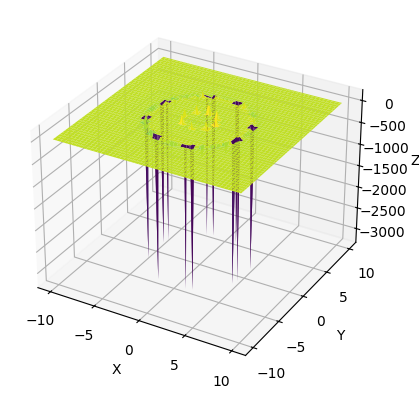

In [86]:
fig = plt.figure()

ax = plt.subplot(projection='3d')
ax.plot_surface(xx,yy,z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()


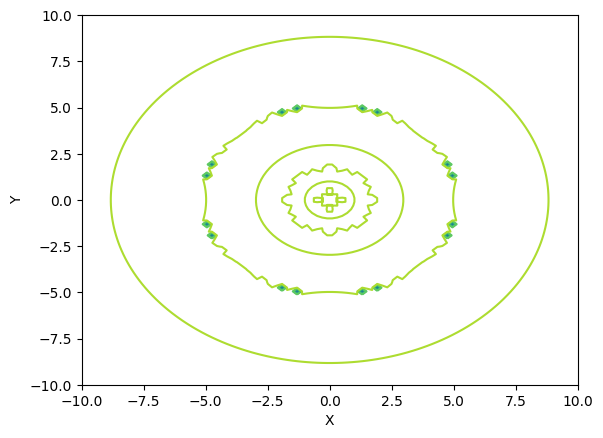

In [87]:
fig = plt.figure()

ax = plt.subplot()
ax.contour(xx,yy,z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()


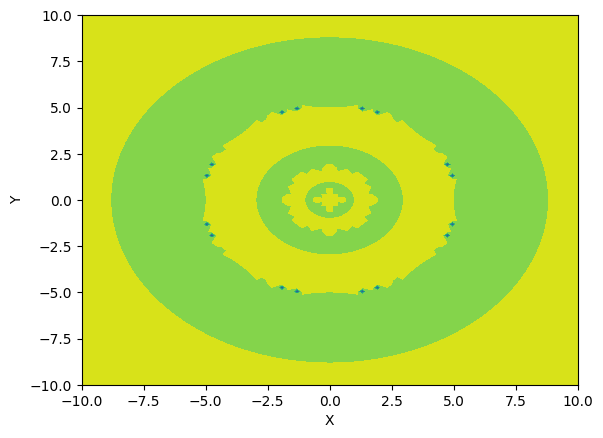

In [89]:
fig = plt.figure()

ax = plt.subplot()
ax.contourf(xx,yy,z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()
